In [ ]:
print("Resume / Candidate Screening System")
print("Future Interns - Machine Learning Task 3")

Resume / Candidate Screening System
Future Interns - Machine Learning Task 3


In [ ]:
!pip install -q spacy nltk scikit-learn pandas matplotlib seaborn

In [ ]:
import pandas as pd
import numpy as np
import re
import nltk
import spacy

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Resume.csv to Resume.csv


In [ ]:
df = pd.read_csv("Resume.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (2484, 4)


In [ ]:
df.head()

,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [ ]:
print("Columns in dataset:")
print(df.columns.tolist())

Columns in dataset:
['ID', 'Resume_str', 'Resume_html', 'Category']


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2484 entries, 0 to 2483
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ID           2484 non-null   int64 
 1   Resume_str   2484 non-null   object
 2   Resume_html  2484 non-null   object
 3   Category     2484 non-null   object
dtypes: int64(1), object(3)
memory usage: 77.8+ KB


In [ ]:
print(df.isnull().sum())

ID             0
Resume_str     0
Resume_html    0
Category       0
dtype: int64


In [ ]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'[^a-zA-Z0-9+#.\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

df["clean_resume"] = df["Resume_str"].apply(clean_text)

df[["Resume_str", "clean_resume"]].head()

,Resume_str,clean_resume
0,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,hr administrator marketing associate hr admini...
1,"HR SPECIALIST, US HR OPERATIONS ...",hr specialist us hr operations summary versati...
2,HR DIRECTOR Summary Over 2...,hr director summary over 20 years experience i...
3,HR SPECIALIST Summary Dedica...,hr specialist summary dedicated driven and dyn...
4,HR MANAGER Skill Highlights ...,hr manager skill highlights hr skills hr depar...


In [ ]:
skills = [
    "python", "java", "c++", "c", "sql", "mysql",
    "machine learning", "deep learning", "artificial intelligence",
    "data science", "pandas", "numpy", "scikit-learn",
    "tensorflow", "keras", "pytorch", "nlp",
    "html", "css", "javascript", "react", "node.js",
    "mongodb", "excel", "power bi", "tableau",
    "git", "github", "aws", "azure",
    "docker", "linux", "communication",
    "project management", "leadership"
]

def extract_skills(text):
    found = []
    text = text.lower()

    for skill in skills:
        if skill in text:
            found.append(skill)

    return list(set(found))

df["extracted_skills"] = df["clean_resume"].apply(extract_skills)

df[["Category", "extracted_skills"]].head(10)

,Category,extracted_skills
0,HR,"[leadership, aws, c]"
1,HR,"[project management, communication, c, git]"
2,HR,"[leadership, c, project management, excel]"
3,HR,"[communication, c, excel]"
4,HR,"[leadership, c, aws, project management, excel]"
5,HR,"[c, excel]"
6,HR,"[leadership, c, project management]"
7,HR,"[communication, aws, c, project management]"
8,HR,"[communication, leadership, c, aws, project ma..."
9,HR,"[aws, c]"


In [ ]:
documents = [job_clean] + df["clean_resume"].tolist()

tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=10000
)

tfidf_matrix = tfidf.fit_transform(documents)

job_vector = tfidf_matrix[0]
resume_vectors = tfidf_matrix[1:]

similarity_scores = cosine_similarity(
    job_vector,
    resume_vectors
).flatten()

df["match_score"] = similarity_scores * 100

df[["Category", "match_score"]].head()

NameError: name 'job_clean' is not defined

In [ ]:
job_description = """
We are looking for a Machine Learning Engineer with strong skills in
Python, Machine Learning, Deep Learning, Artificial Intelligence,
Data Science, Pandas, NumPy, Scikit-learn, TensorFlow, NLP,
SQL and Git. The candidate should have good communication skills
and experience in developing machine learning projects.
"""

job_clean = clean_text(job_description)

print("Job Description created successfully!")
print(job_clean)

Job Description created successfully!
we are looking for a machine learning engineer with strong skills in python machine learning deep learning artificial intelligence data science pandas numpy scikit learn tensorflow nlp sql and git. the candidate should have good communication skills and experience in developing machine learning projects.


In [ ]:
documents = [job_clean] + df["clean_resume"].tolist()

tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=10000
)

tfidf_matrix = tfidf.fit_transform(documents)

job_vector = tfidf_matrix[0]
resume_vectors = tfidf_matrix[1:]

similarity_scores = cosine_similarity(
    job_vector,
    resume_vectors
).flatten()

df["match_score"] = similarity_scores * 100

df[["Category", "match_score"]].head()

,Category,match_score
0,HR,0.717014
1,HR,0.719460
2,HR,0.505432
3,HR,0.770964
4,HR,0.250446


In [ ]:
df["match_score"] = similarity_scores * 100

df[["Category", "match_score"]].head()

,Category,match_score
0,HR,0.717014
1,HR,0.719460
2,HR,0.505432
3,HR,0.770964
4,HR,0.250446


In [ ]:
ranked_candidates = df.sort_values(
    by="match_score",
    ascending=False
).reset_index(drop=True)

ranked_candidates["Rank"] = ranked_candidates.index + 1

ranked_candidates[
    ["Rank", "Category", "match_score", "extracted_skills"]
].head(10)

,Rank,Category,match_score,extracted_skills
0,1,ARTS,20.042737,"[leadership, c]"
1,2,DESIGNER,19.468579,"[c, project management]"
2,3,BANKING,18.634448,"[python, sql, machine learning, c, c++]"
3,4,ENGINEERING,18.418023,"[python, tableau, sql, machine learning, c, ht..."
4,5,AGRICULTURE,15.433753,"[react, communication, python, tableau, sql, t..."
5,6,TEACHER,14.882878,"[communication, leadership, c, excel]"
6,7,TEACHER,14.136213,"[communication, c, git]"
7,8,CONSULTANT,14.013186,"[python, sql, data science, azure, machine lea..."
8,9,AUTOMOBILE,13.531172,"[python, sql, machine learning, c, java, excel]"
9,10,TEACHER,13.080239,"[c, git]"


In [ ]:
required_skills = set([
    "python",
    "machine learning",
    "deep learning",
    "artificial intelligence",
    "data science",
    "pandas",
    "numpy",
    "scikit-learn",
    "tensorflow",
    "nlp",
    "sql",
    "git",
    "communication"
])

def find_missing_skills(candidate_skills):
    candidate_skills = set(candidate_skills)
    return sorted(required_skills - candidate_skills)

ranked_candidates["missing_skills"] = ranked_candidates[
    "extracted_skills"
].apply(find_missing_skills)

ranked_candidates[
    ["Rank", "Category", "match_score",
     "extracted_skills", "missing_skills"]
].head(10)

,Rank,Category,match_score,extracted_skills,missing_skills
0,1,ARTS,20.042737,"[leadership, c]","[artificial intelligence, communication, data ..."
1,2,DESIGNER,19.468579,"[c, project management]","[artificial intelligence, communication, data ..."
2,3,BANKING,18.634448,"[python, sql, machine learning, c, c++]","[artificial intelligence, communication, data ..."
3,4,ENGINEERING,18.418023,"[python, tableau, sql, machine learning, c, ht...","[artificial intelligence, communication, data ..."
4,5,AGRICULTURE,15.433753,"[react, communication, python, tableau, sql, t...","[artificial intelligence, data science, deep l..."
5,6,TEACHER,14.882878,"[communication, leadership, c, excel]","[artificial intelligence, data science, deep l..."
6,7,TEACHER,14.136213,"[communication, c, git]","[artificial intelligence, data science, deep l..."
7,8,CONSULTANT,14.013186,"[python, sql, data science, azure, machine lea...","[artificial intelligence, communication, deep ..."
8,9,AUTOMOBILE,13.531172,"[python, sql, machine learning, c, java, excel]","[artificial intelligence, communication, data ..."
9,10,TEACHER,13.080239,"[c, git]","[artificial intelligence, communication, data ..."


In [ ]:
top_10 = ranked_candidates.head(10)

print("TOP 10 CANDIDATES")
print("=" * 60)

for _, row in top_10.iterrows():
    print("Rank:", row["Rank"])
    print("Category:", row["Category"])
    print("Match Score:", round(row["match_score"], 2), "%")
    print("Skills:", ", ".join(row["extracted_skills"]))
    print("Missing Skills:", ", ".join(row["missing_skills"]))
    print("-" * 60)

TOP 10 CANDIDATES
Rank: 1
Category: ARTS
Match Score: 20.04 %
Skills: leadership, c
Missing Skills: artificial intelligence, communication, data science, deep learning, git, machine learning, nlp, numpy, pandas, python, scikit-learn, sql, tensorflow
------------------------------------------------------------
Rank: 2
Category: DESIGNER
Match Score: 19.47 %
Skills: c, project management
Missing Skills: artificial intelligence, communication, data science, deep learning, git, machine learning, nlp, numpy, pandas, python, scikit-learn, sql, tensorflow
------------------------------------------------------------
Rank: 3
Category: BANKING
Match Score: 18.63 %
Skills: python, sql, machine learning, c, c++
Missing Skills: artificial intelligence, communication, data science, deep learning, git, nlp, numpy, pandas, scikit-learn, tensorflow
------------------------------------------------------------
Rank: 4
Category: ENGINEERING
Match Score: 18.42 %
Skills: python, tableau, sql, machine learni

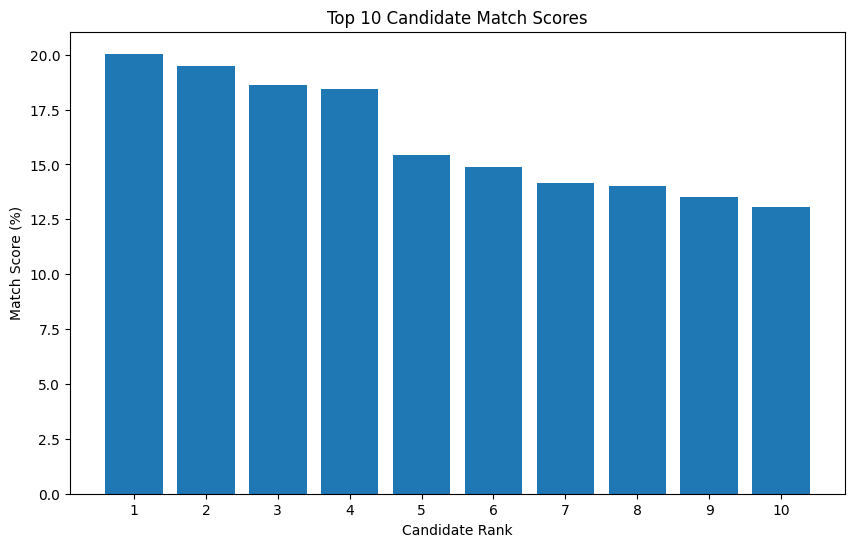

In [ ]:
plt.figure(figsize=(10, 6))

plt.bar(
    top_10["Rank"].astype(str),
    top_10["match_score"]
)

plt.xlabel("Candidate Rank")
plt.ylabel("Match Score (%)")
plt.title("Top 10 Candidate Match Scores")

plt.show()

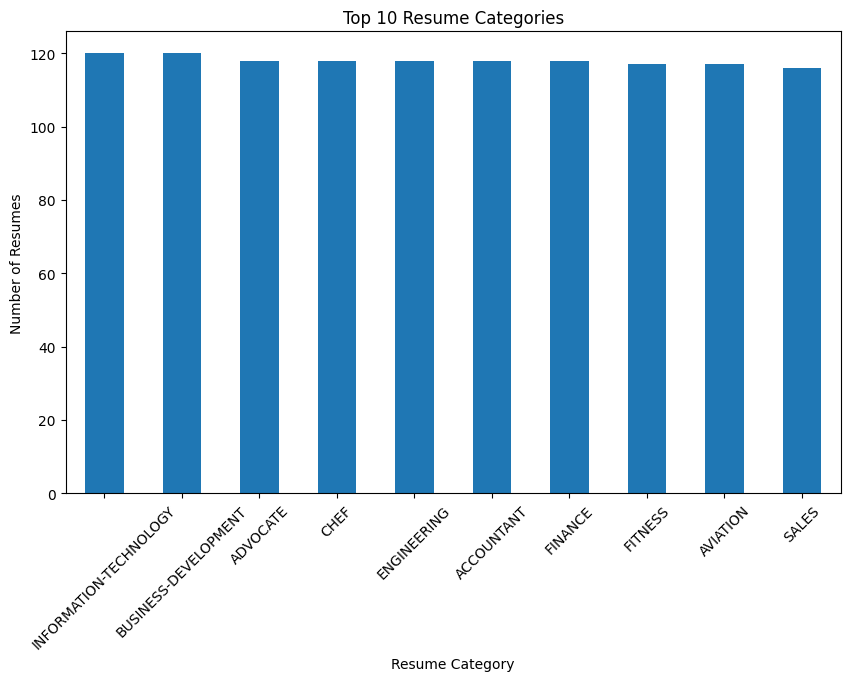

In [ ]:
plt.figure(figsize=(10, 6))

df["Category"].value_counts().head(10).plot(kind="bar")

plt.xlabel("Resume Category")
plt.ylabel("Number of Resumes")
plt.title("Top 10 Resume Categories")

plt.xticks(rotation=45)
plt.show()

In [ ]:
new_resume = """
Python developer with experience in machine learning, data science,
pandas, numpy, scikit-learn, SQL and artificial intelligence.
Experienced in developing NLP and deep learning projects.
Good communication and problem solving skills.
"""

new_resume_clean = clean_text(new_resume)

new_vector = tfidf.transform([new_resume_clean])

new_score = cosine_similarity(
    new_vector,
    job_vector
)[0][0] * 100

new_skills = extract_skills(new_resume_clean)

missing_new_skills = sorted(
    required_skills - set(new_skills)
)

print("NEW CANDIDATE SCREENING")
print("=" * 50)
print("Match Score:", round(new_score, 2), "%")
print("Detected Skills:", ", ".join(new_skills))
print("Missing Skills:", ", ".join(missing_new_skills))

NEW CANDIDATE SCREENING
Match Score: 78.47 %
Detected Skills: communication, python, sql, data science, machine learning, artificial intelligence, deep learning, c, numpy, pandas, nlp
Missing Skills: git, scikit-learn, tensorflow


In [ ]:
final_results = ranked_candidates[
    [
        "Rank",
        "Category",
        "match_score",
        "extracted_skills",
        "missing_skills"
    ]
]

final_results.to_csv(
    "resume_screening_results.csv",
    index=False
)

print("Final results saved successfully!")

Final results saved successfully!


In [ ]:
from google.colab import files

files.download("resume_screening_results.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>